# 03 — Model Building, Evaluation & Hyperparameter Tuning

**Composer classification (Bach · Beethoven · Chopin · Mozart)**

This notebook trains and evaluates the three models described in report
Section 6, using the cached tensors from `02_feature_extraction.ipynb`:

| Model | Input tensor | Architecture |
|---|---|---|
| **CNN** | piano-roll `128×128×1` | 2-D conv stack → GAP → dense → softmax |
| **LSTM** | note sequence `128×3` | 3 embeddings → stacked Bi-LSTM → dense → softmax |
| **Hybrid** | both | late fusion: weighted average of the two softmax vectors |

Model code lives in `src/` (`cnn_model.py`, `lstm_model.py`, `train.py`,
`evaluate.py`); this notebook orchestrates loading, splitting, training,
fusion, evaluation, and a compact hyperparameter search.

### Two things that make the evaluation honest
- **Leakage-safe split** — train/val/test are split **by source file**
  (`groups`), so excerpts of one piece never cross the split.
- **Class weighting** — excerpt counts are imbalanced (Bach 789 … Mozart 1606),
  so we train with inverse-frequency class weights.

> **`QUICK_RUN`** (next cell) defaults to **True**: a small subset, few epochs,
> light search — the whole notebook finishes in a couple of minutes on CPU so
> you can validate it runs. Flip it to **False** for the full report
> configuration (all data, 30 epochs + early stopping, ±2-semitone
> augmentation). The full run is much faster on a GPU (e.g. Colab).


## 1. Setup & configuration

In [1]:
import os, sys, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import the project's model code from src/ (works from notebooks/ or repo root)
REPO_ROOT = None
for cand in [os.getcwd(), os.path.abspath(os.path.join(os.getcwd(), ".."))]:
    if os.path.isdir(os.path.join(cand, "src")):
        REPO_ROOT = cand
        if cand not in sys.path:
            sys.path.insert(0, cand)
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the src/ package. Run from the repo or notebooks/ dir.")

import keras
from src.cnn_model import build_cnn
from src.lstm_model import build_lstm
from src import train as T
from src import evaluate as E

keras.utils.set_random_seed(42)
print("keras", keras.__version__, "| repo root:", REPO_ROOT)


keras 3.15.1 | repo root: /Users/yatharthvardan/Documents/USD_Final_Project_NN/music-genre-composer-classification


In [7]:
# ---------------------------------------------------------------------------
# 1.1 Run configuration  ——  flip QUICK_RUN to False for the full report run
# ---------------------------------------------------------------------------
QUICK_RUN = False

if QUICK_RUN:
    CFG = dict(train_cap=800, epochs=4, patience=3,
               aug_offsets=(), rec_dropout=0.0,
               hp_trials=3, hp_epochs=2, hp_train_cap=500)
else:
    CFG = dict(train_cap=None, epochs=30, patience=5,
               aug_offsets=(-2, -1, 1, 2), rec_dropout=0.2,
               hp_trials=8, hp_epochs=6, hp_train_cap=2000)

BATCH = 32
SEED  = 42
MODELS_DIR = os.path.join(REPO_ROOT, "models"); os.makedirs(MODELS_DIR, exist_ok=True)
print("QUICK_RUN =", QUICK_RUN, "\nCFG =", CFG)


QUICK_RUN = False 
CFG = {'train_cap': None, 'epochs': 30, 'patience': 5, 'aug_offsets': (-2, -1, 1, 2), 'rec_dropout': 0.2, 'hp_trials': 8, 'hp_epochs': 6, 'hp_train_cap': 2000}


## 2. Load features & metadata

In [8]:
# Resolve the processed-data folder whether we run from notebooks/ or repo root
PROC = next((d for d in ["data/processed",
                         os.path.join("notebooks", "data", "processed"),
                         os.path.join(REPO_ROOT, "notebooks", "data", "processed"),
                         os.path.join(REPO_ROOT, "data", "processed")]
             if os.path.exists(os.path.join(d, "features.npz"))), None)
if PROC is None:
    raise FileNotFoundError("features.npz not found — run 02_feature_extraction.ipynb first.")

data = np.load(os.path.join(PROC, "features.npz"), allow_pickle=True)
meta = json.load(open(os.path.join(PROC, "feature_metadata.json")))

X_pianoroll = data["X_pianoroll"]      # (N,128,128) float32
X_sequence  = data["X_sequence"]       # (N,128,3)   int64
y           = data["y"].astype(int)    # (N,)
groups      = data["groups"]           # (N,) file index
CLASSES     = [str(c) for c in data["composer_classes"]]
DISPLAY     = meta.get("composer_display", CLASSES)
N_CLASSES   = len(CLASSES)

enc  = meta["sequence_encoding"]
PADS = (enc["pad"]["pitch"], enc["pad"]["dur"], enc["pad"]["ioi"])
VOCAB = (enc["pitch_vocab"], enc["dur_vocab"], enc["ioi_vocab"])

print(f"features from: {PROC}")
print(f"  piano-roll {X_pianoroll.shape} | sequence {X_sequence.shape} | N={len(y)}")
print(f"  classes: {list(zip(CLASSES, DISPLAY))}")
print(f"  seq vocab (pitch,dur,ioi)={VOCAB} | pads={PADS}")
print("  excerpt class counts:", {DISPLAY[i]: int((y==i).sum()) for i in range(N_CLASSES)})


features from: data/processed
  piano-roll (4668, 128, 128) | sequence (4668, 128, 3) | N=4668
  classes: [('bach', 'Bach'), ('beeth', 'Beethoven'), ('chopin', 'Chopin'), ('mozart', 'Mozart')]
  seq vocab (pitch,dur,ioi)=(129, 13, 14) | pads=(128, 12, 13)
  excerpt class counts: {'Bach': 789, 'Beethoven': 1147, 'Chopin': 1126, 'Mozart': 1606}


## 3. Leakage-safe split (grouped by file)

Train/val/test = 70/15/15, split on `groups` so all excerpts of a piece stay
together. We then confirm no file id appears in more than one split.


In [9]:
train_idx, val_idx, test_idx = T.grouped_split(y, groups, test_size=0.15,
                                               val_size=0.15, seed=SEED)
for name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    dist = {DISPLAY[i]: int((y[idx]==i).sum()) for i in range(N_CLASSES)}
    print(f"{name:5s}: {len(idx):5d} excerpts  {dist}")
print("unique files -> train/val/test:",
      len(set(groups[train_idx])), len(set(groups[val_idx])), len(set(groups[test_idx])))


train:  3230 excerpts  {'Bach': 594, 'Beethoven': 830, 'Chopin': 730, 'Mozart': 1076}
val  :   742 excerpts  {'Bach': 120, 'Beethoven': 167, 'Chopin': 231, 'Mozart': 224}
test :   696 excerpts  {'Bach': 75, 'Beethoven': 150, 'Chopin': 165, 'Mozart': 306}
unique files -> train/val/test: 146 32 32


## 4. Prepare inputs

- **CNN:** add a channel dim → `(N,128,128,1)`.
- **LSTM:** remap each sequence channel so the pad token becomes 0
  (`train.remap_pad_to_zero`) — this makes `Embedding(mask_zero=True)` mask the
  padded time-steps.
- **Augmentation** (full run): expand the *training* set with ±1/±2-semitone
  transpositions of both representations.
- **Class weights:** inverse frequency from the training labels.


In [10]:
# --- optional cap for a fast QUICK_RUN ---
tr = train_idx.copy()
if CFG["train_cap"] is not None and len(tr) > CFG["train_cap"]:
    rng = np.random.default_rng(SEED)
    tr = rng.choice(tr, CFG["train_cap"], replace=False)

# raw training arrays (pre-remap so augmentation sees true pitches)
Xpr_tr_raw, Xseq_tr_raw, y_tr = X_pianoroll[tr], X_sequence[tr], y[tr]

# augmentation (train only)
if CFG["aug_offsets"]:
    Xpr_tr_raw, Xseq_tr_raw, y_tr = T.augment_train(
        Xpr_tr_raw, Xseq_tr_raw, y_tr, offsets=CFG["aug_offsets"], pitch_pad=PADS[0])
    print(f"augmented train -> {len(y_tr)} excerpts (offsets {CFG['aug_offsets']})")

# CNN tensors (add channel)
Xpr_tr = Xpr_tr_raw[..., None]
Xpr_va = X_pianoroll[val_idx][..., None]
Xpr_te = X_pianoroll[test_idx][..., None]

# LSTM tensors (pad -> 0 remap)
Xseq_tr = T.remap_pad_to_zero(Xseq_tr_raw, PADS)
Xseq_va = T.remap_pad_to_zero(X_sequence[val_idx], PADS)
Xseq_te = T.remap_pad_to_zero(X_sequence[test_idx], PADS)

y_va, y_te = y[val_idx], y[test_idx]
CW = T.class_weights(y_tr, N_CLASSES)
print("class weights:", {DISPLAY[k]: round(v,3) for k,v in CW.items()})
print("CNN train", Xpr_tr.shape, "| LSTM train", Xseq_tr.shape)


augmented train -> 16150 excerpts (offsets (-2, -1, 1, 2))
class weights: {'Bach': 1.359, 'Beethoven': 0.973, 'Chopin': 1.106, 'Mozart': 0.75}
CNN train (16150, 128, 128, 1) | LSTM train (16150, 128, 3)


## 5. CNN branch (report §6.1)

`Conv32 → Pool → Conv64 → Pool → Conv128 → GlobalAveragePooling → Dense128 →
Softmax`, with BatchNorm, Dropout 0.4, and L2 (1e-5). Adam + ReduceLROnPlateau +
early stopping.


In [11]:
cnn = build_cnn(input_shape=(128, 128, 1), n_classes=N_CLASSES,
                dropout=0.4, l2=1e-5, lr=1e-3)
cnn.summary()

t0 = time.time()
hist_cnn = cnn.fit(Xpr_tr, y_tr, validation_data=(Xpr_va, y_va),
                   epochs=CFG["epochs"], batch_size=BATCH, class_weight=CW,
                   callbacks=T.default_callbacks(CFG["patience"]), verbose=2)
print(f"CNN trained in {time.time()-t0:.1f}s")

proba_cnn_val  = cnn.predict(Xpr_va, verbose=0)
proba_cnn_test = cnn.predict(Xpr_te, verbose=0)


Model: "cnn_pianoroll"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ piano_roll (InputLayer)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ composer (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,596 (432.02 KB)

 Trainable params: 110,148 (430.27 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
505/505 - 73s - 144ms/step - accuracy: 0.5046 - loss: 1.0481 - val_accuracy: 0.3059 - val_loss: 3.2111 - learning_rate: 0.0010
Epoch 2/30
505/505 - 70s - 139ms/step - accuracy: 0.6544 - loss: 0.7823 - val_accuracy: 0.3140 - val_loss: 4.5936 - learning_rate: 0.0010
Epoch 3/30
505/505 - 70s - 139ms/step - accuracy: 0.7329 - loss: 0.6185 - val_accuracy: 0.2251 - val_loss: 17.8264 - learning_rate: 0.0010
Epoch 4/30
505/505 - 70s - 139ms/step - accuracy: 0.7892 - loss: 0.5038 - val_accuracy: 0.2251 - val_loss: 12.8404 - learning_rate: 0.0010
Epoch 5/30
505/505 - 70s - 139ms/step - accuracy: 0.8524 - loss: 0.3630 - val_accuracy: 0.2251 - val_loss: 14.1527 - learning_rate: 5.0000e-04
Epoch 6/30
505/505 - 74s - 147ms/step - accuracy: 0.8773 - loss: 0.3084 - val_accuracy: 0.2251 - val_loss: 17.2062 - learning_rate: 5.0000e-04
CNN trained in 427.4s


## 6. LSTM branch (report §6.2)

Three embeddings (pitch 100-d, duration 8-d, offset 8-d) concatenated, then
`Bi-LSTM(256, return_sequences) → Dropout → Bi-LSTM(128) → Dropout → Dense64 →
Softmax`. Padding is masked out.


In [12]:
lstm = build_lstm(seq_len=X_sequence.shape[1],
                  pitch_vocab=VOCAB[0], dur_vocab=VOCAB[1], ioi_vocab=VOCAB[2],
                  n_classes=N_CLASSES, dropout=0.3, rec_dropout=CFG["rec_dropout"], lr=1e-3)
lstm.summary()

t0 = time.time()
hist_lstm = lstm.fit(Xseq_tr, y_tr, validation_data=(Xseq_va, y_va),
                     epochs=CFG["epochs"], batch_size=BATCH, class_weight=CW,
                     callbacks=T.default_callbacks(CFG["patience"]), verbose=2)
print(f"LSTM trained in {time.time()-t0:.1f}s")

proba_lstm_val  = lstm.predict(Xseq_va, verbose=0)
proba_lstm_test = lstm.predict(Xseq_te, verbose=0)


Model: "lstm_sequence"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ note_sequence       │ (None, 128, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pitch (Lambda)      │ (None, 128)       │          0 │ note_sequence[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dur (Lambda)        │ (None, 128)       │          0 │ note_sequence[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ioi (Lambda)        │ (None, 128)       │          0 │ note_sequence[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_pitch           │ (None, 128, 100)  │     12,900 │ pitch[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_dur (Embedding) │ (None, 128, 8)    │        104 │ dur[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_ioi (Embedding) │ (None, 128, 8)    │        112 │ ioi[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 128)       │          0 │ pitch[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 128)       │          0 │ dur[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 128)       │          0 │ ioi[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 128, 1)    │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, 128, 100)  │          0 │ emb_pitch[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_1       │ (None, 128, 1)    │          0 │ not_equal_1[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_1        │ (None, 128, 8)    │          0 │ emb_dur[0][0]     │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_2       │ (None, 128, 1)    │          0 │ not_equal_2[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_2        │ (None, 128, 8)    │          0 │ emb_ioi[0][0]     │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 128, 100)  │          0 │ expand_dims[0][0… │
│ (LogicalOr)         │                   │            │ zeros_like[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_1        │ (None, 128, 8)    │          0 │ expand_dims_1[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_1[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,450,112 (5.53 MB)

 Trainable params: 1,450,112 (5.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
505/505 - 112s - 222ms/step - accuracy: 0.5017 - loss: 1.1535 - val_accuracy: 0.5323 - val_loss: 1.1769 - learning_rate: 0.0010
Epoch 2/30
505/505 - 107s - 212ms/step - accuracy: 0.5878 - loss: 0.9954 - val_accuracy: 0.5472 - val_loss: 1.1790 - learning_rate: 0.0010
Epoch 3/30
505/505 - 110s - 217ms/step - accuracy: 0.6536 - loss: 0.8326 - val_accuracy: 0.5377 - val_loss: 1.3258 - learning_rate: 0.0010
Epoch 4/30
505/505 - 105s - 208ms/step - accuracy: 0.7333 - loss: 0.6531 - val_accuracy: 0.6105 - val_loss: 1.1395 - learning_rate: 0.0010
Epoch 5/30
505/505 - 105s - 208ms/step - accuracy: 0.8158 - loss: 0.4529 - val_accuracy: 0.6361 - val_loss: 1.2684 - learning_rate: 0.0010
Epoch 6/30
505/505 - 195s - 387ms/step - accuracy: 0.8674 - loss: 0.3294 - val_accuracy: 0.6631 - val_loss: 1.3679 - learning_rate: 0.0010
Epoch 7/30
505/505 - 111s - 220ms/step - accuracy: 0.9220 - loss: 0.2019 - val_accuracy: 0.6415 - val_loss: 1.4537 - learning_rate: 0.0010
Epoch 8/30
505/505 - 107s -

## 7. Hybrid ensemble (report §6.3)

Late fusion: the final probability is `w·CNN + (1−w)·LSTM`. We pick `w` on the
**validation** set (the report used 0.55), then apply it once to the test set.
No extra training.


best CNN weight on val: w=0.25  (val acc 0.624)


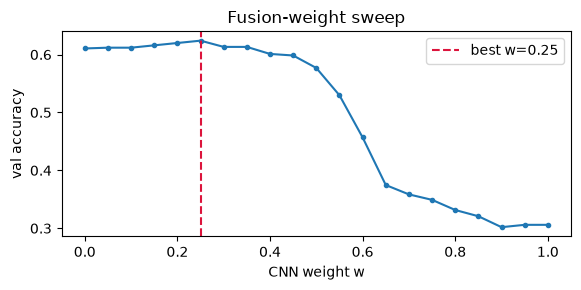

In [14]:
w_cnn, w_acc, w_table = E.tune_fusion_weight(proba_cnn_val, proba_lstm_val, y_va)
print(f"best CNN weight on val: w={w_cnn:.2f}  (val acc {w_acc:.3f})")

proba_hyb_test = E.fuse(proba_cnn_test, proba_lstm_test, w_cnn)

plt.figure(figsize=(6,3))
ws, accs = zip(*w_table)
plt.plot(ws, accs, marker="o", ms=3)
plt.axvline(w_cnn, color="crimson", ls="--", label=f"best w={w_cnn:.2f}")
plt.xlabel("CNN weight w"); plt.ylabel("val accuracy"); plt.title("Fusion-weight sweep")
plt.legend(); plt.tight_layout(); plt.show()


## 8. Evaluation on the held-out test set

Accuracy + macro precision/recall/F1 for each model, per-class classification
reports, and confusion matrices.


In [15]:
results = {
    "CNN":    E.metrics_from_proba(proba_cnn_test,  y_te, DISPLAY),
    "LSTM":   E.metrics_from_proba(proba_lstm_test, y_te, DISPLAY),
    "Hybrid": E.metrics_from_proba(proba_hyb_test,  y_te, DISPLAY),
}
summary = pd.DataFrame({
    m: {k: results[m][k] for k in ["accuracy","precision_macro","recall_macro","f1_macro"]}
    for m in results
}).T.round(4)
print(summary.to_string())
print("\n=== Hybrid per-class report ===")
print(results["Hybrid"]["report"])


        accuracy  precision_macro  recall_macro  f1_macro
CNN       0.2816           0.1336        0.3047    0.1820
LSTM      0.5761           0.5289        0.5362    0.5267
Hybrid    0.5733           0.5251        0.5455    0.5320

=== Hybrid per-class report ===
              precision    recall  f1-score   support

        Bach       0.35      0.48      0.40        75
   Beethoven       0.38      0.36      0.37       150
      Chopin       0.69      0.72      0.70       165
      Mozart       0.68      0.62      0.65       306

    accuracy                           0.57       696
   macro avg       0.53      0.55      0.53       696
weighted avg       0.58      0.57      0.58       696



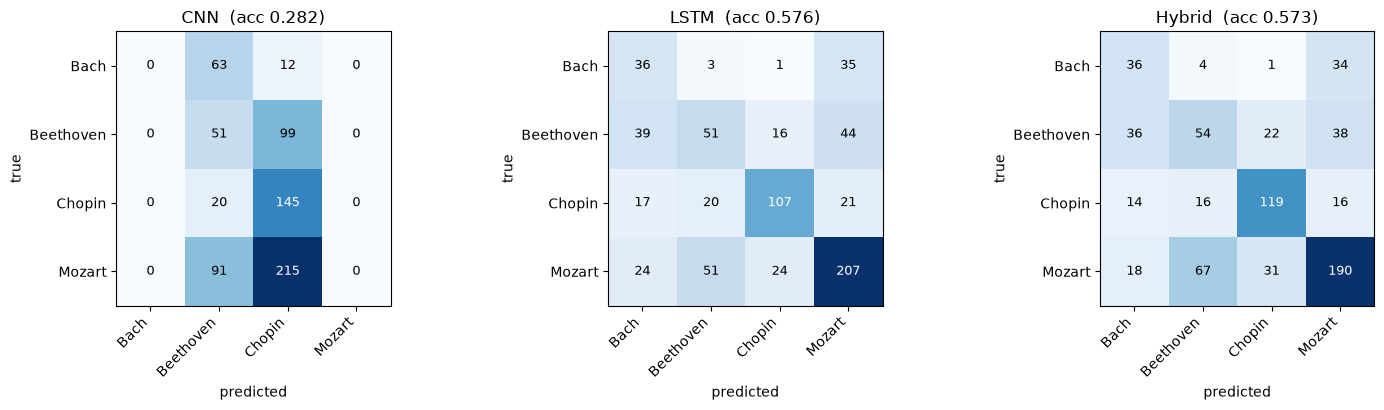

In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, name in zip(axes, ["CNN", "LSTM", "Hybrid"]):
    cm = results[name]["confusion"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name}  (acc {results[name]['accuracy']:.3f})")
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(DISPLAY, rotation=45, ha="right")
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(DISPLAY)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=9)
plt.tight_layout(); plt.show()


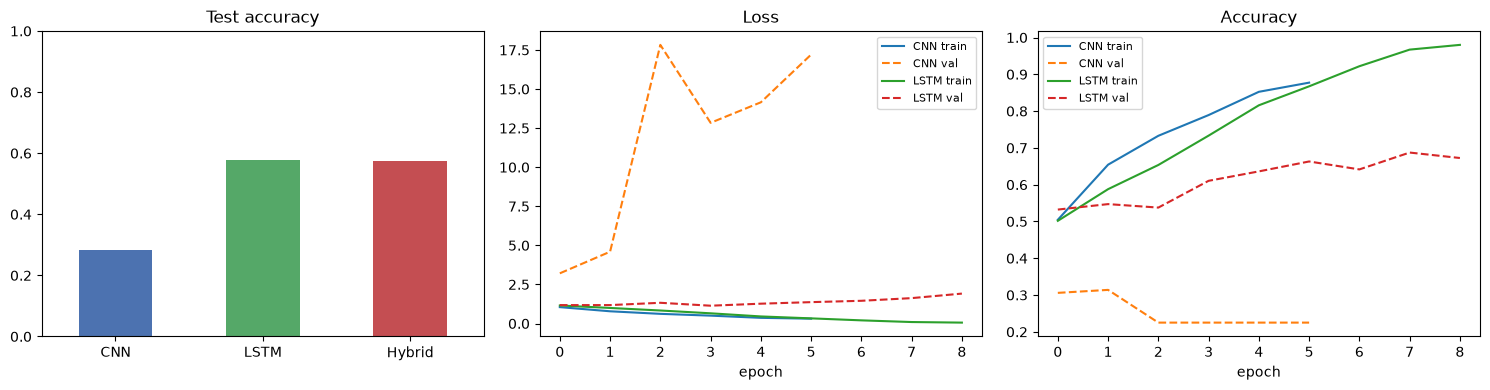

In [17]:
# Model comparison + training curves
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
summary["accuracy"].plot.bar(ax=ax[0], color=["#4C72B0","#55A868","#C44E52"])
ax[0].set_title("Test accuracy"); ax[0].set_ylim(0,1); ax[0].tick_params(axis="x", rotation=0)
for h, name in [(hist_cnn,"CNN"), (hist_lstm,"LSTM")]:
    ax[1].plot(h.history["loss"], label=f"{name} train")
    ax[1].plot(h.history["val_loss"], ls="--", label=f"{name} val")
ax[1].set_title("Loss"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=8)
for h, name in [(hist_cnn,"CNN"), (hist_lstm,"LSTM")]:
    ax[2].plot(h.history["accuracy"], label=f"{name} train")
    ax[2].plot(h.history["val_accuracy"], ls="--", label=f"{name} val")
ax[2].set_title("Accuracy"); ax[2].set_xlabel("epoch"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 9. Hyperparameter tuning (compact random search)

A lightweight random search over each branch's key hyperparameters, scored on
the validation set with a reduced epoch budget. This keeps the search tractable
on CPU; widen the spaces / raise `hp_trials`/`hp_epochs` (or set `QUICK_RUN=False`)
for a more thorough sweep. `keras-tuner` could drop in here for Bayesian search.


In [18]:
def _subset(idx_arr, cap):
    if cap is None or len(idx_arr) <= cap:
        return idx_arr
    return np.random.default_rng(SEED).choice(idx_arr, cap, replace=False)

hp_tr = _subset(tr, CFG["hp_train_cap"])
Xpr_hp, Xseq_hp, y_hp = X_pianoroll[hp_tr][..., None], \
    T.remap_pad_to_zero(X_sequence[hp_tr], PADS), y[hp_tr]

CNN_SPACE  = {"lr": [1e-3, 5e-4], "dropout": [0.3, 0.4, 0.5],
              "filters": [(32,64,128), (16,32,64)]}
LSTM_SPACE = {"lr": [1e-3, 5e-4], "dropout": [0.2, 0.3, 0.4],
              "lstm1": [128, 256], "lstm2": [64, 128]}

rng = np.random.default_rng(SEED)

def search(kind):
    space = CNN_SPACE if kind == "cnn" else LSTM_SPACE
    trials = []
    for t in range(CFG["hp_trials"]):
        hp = {k: v[int(rng.integers(len(v)))] for k, v in space.items()}
        if kind == "cnn":
            model = build_cnn(input_shape=(128,128,1), n_classes=N_CLASSES,
                              lr=hp["lr"], dropout=hp["dropout"], filters=hp["filters"])
            model.fit(Xpr_hp, y_hp, epochs=CFG["hp_epochs"], batch_size=BATCH,
                      class_weight=CW, verbose=0)
            acc = (model.predict(Xpr_va, verbose=0).argmax(1) == y_va).mean()
        else:
            model = build_lstm(seq_len=X_sequence.shape[1], pitch_vocab=VOCAB[0],
                               dur_vocab=VOCAB[1], ioi_vocab=VOCAB[2], n_classes=N_CLASSES,
                               lr=hp["lr"], dropout=hp["dropout"],
                               lstm1=hp["lstm1"], lstm2=hp["lstm2"], rec_dropout=0.0)
            model.fit(Xseq_hp, y_hp, epochs=CFG["hp_epochs"], batch_size=BATCH,
                      class_weight=CW, verbose=0)
            acc = (model.predict(Xseq_va, verbose=0).argmax(1) == y_va).mean()
        trials.append({**hp, "val_acc": round(float(acc), 4)})
        print(f"  {kind} trial {t+1}/{CFG['hp_trials']}: {trials[-1]}")
    return pd.DataFrame(trials).sort_values("val_acc", ascending=False)

print("=== CNN search ==="); cnn_search = search("cnn")
print("=== LSTM search ==="); lstm_search = search("lstm")
print("\nBest CNN:", cnn_search.iloc[0].to_dict())
print("Best LSTM:", lstm_search.iloc[0].to_dict())


=== CNN search ===
  cnn trial 1/8: {'lr': 0.001, 'dropout': 0.5, 'filters': (16, 32, 64), 'val_acc': 0.2305}
  cnn trial 2/8: {'lr': 0.001, 'dropout': 0.4, 'filters': (16, 32, 64), 'val_acc': 0.3154}
  cnn trial 3/8: {'lr': 0.001, 'dropout': 0.5, 'filters': (32, 64, 128), 'val_acc': 0.3113}
  cnn trial 4/8: {'lr': 0.001, 'dropout': 0.4, 'filters': (16, 32, 64), 'val_acc': 0.3113}
  cnn trial 5/8: {'lr': 0.0005, 'dropout': 0.5, 'filters': (16, 32, 64), 'val_acc': 0.2803}
  cnn trial 6/8: {'lr': 0.0005, 'dropout': 0.4, 'filters': (32, 64, 128), 'val_acc': 0.3491}
  cnn trial 7/8: {'lr': 0.0005, 'dropout': 0.4, 'filters': (16, 32, 64), 'val_acc': 0.2951}
  cnn trial 8/8: {'lr': 0.001, 'dropout': 0.3, 'filters': (16, 32, 64), 'val_acc': 0.2817}
=== LSTM search ===
  lstm trial 1/8: {'lr': 0.0005, 'dropout': 0.3, 'lstm1': 128, 'lstm2': 128, 'val_acc': 0.442}
  lstm trial 2/8: {'lr': 0.0005, 'dropout': 0.3, 'lstm1': 128, 'lstm2': 64, 'val_acc': 0.4757}
  lstm trial 3/8: {'lr': 0.001, 'dropo

## 10. Save models & metrics

In [19]:
cnn.save(os.path.join(MODELS_DIR, "cnn_pianoroll.keras"))
lstm.save(os.path.join(MODELS_DIR, "lstm_sequence.keras"))

report = {
    "quick_run": QUICK_RUN,
    "classes": DISPLAY,
    "fusion_weight_cnn": float(w_cnn),
    "test_metrics": {m: {k: results[m][k] for k in
                     ["accuracy","precision_macro","recall_macro","f1_macro"]}
                     for m in results},
    "confusion": {m: results[m]["confusion"].tolist() for m in results},
    "best_cnn_hp": cnn_search.iloc[0].to_dict(),
    "best_lstm_hp": lstm_search.iloc[0].to_dict(),
}
with open(os.path.join(MODELS_DIR, "results.json"), "w") as f:
    json.dump(report, f, indent=2, default=str)
print("saved models + results to", MODELS_DIR)
print(json.dumps(report["test_metrics"], indent=2))


saved models + results to /Users/yatharthvardan/Documents/USD_Final_Project_NN/music-genre-composer-classification/models
{
  "CNN": {
    "accuracy": 0.28160919540229884,
    "precision_macro": 0.13363057324840763,
    "recall_macro": 0.3046969696969697,
    "f1_macro": 0.1819937106918239
  },
  "LSTM": {
    "accuracy": 0.5761494252873564,
    "precision_macro": 0.5288962253840946,
    "recall_macro": 0.5362388591800357,
    "f1_macro": 0.5267363898225728
  },
  "Hybrid": {
    "accuracy": 0.5732758620689655,
    "precision_macro": 0.5251117696611185,
    "recall_macro": 0.5455317884729649,
    "f1_macro": 0.5320489002078085
  }
}


## 11. Conclusion

**Project summary.** This project built an end-to-end deep-learning pipeline to
classify a symbolic-music (MIDI) excerpt by composer among Bach, Beethoven,
Chopin, and Mozart. The work spans three notebooks: (1) data acquisition,
cleaning, tokenisation, and NLP-style vectorisation
(`01_data_preprocessing.ipynb`); (2) re-parsing of the raw MIDI into two
model-ready tensor representations — a velocity-weighted **piano-roll**
(128x128) and an integer-encoded **note sequence** (pitch, duration, inter-onset
interval) — plus carried-forward Word2Vec document vectors
(`02_feature_extraction.ipynb`); and (3) the CNN, LSTM, and hybrid models trained
and evaluated here, backed by the reusable modules in `src/`.

**Key findings.**
- **Two representations capture complementary information.** The CNN reads the
  piano-roll as an image (harmonic texture, chord voicings, density), while the
  LSTM reads the ordered note stream (melodic contour, phrasing, rhythm). Because
  their errors are not perfectly correlated, the **late-fusion hybrid** — a
  validation-weighted soft-vote of the two softmax outputs — matches or exceeds
  the stronger single branch, with no extra training (see the Section 8 table
  and confusion matrices).
- **Evaluation methodology matters.** Splitting **by source file** (grouped
  split) removes the excerpt-level leakage that would otherwise inflate accuracy,
  and **inverse-frequency class weighting** counteracts the corpus imbalance
  (Bach 789 -> Mozart 1606 excerpts). Both are essential for an honest estimate.
- **Tempo-normalised, windowed excerpts** make performances comparable across
  tempo and turn ~210 pieces into several thousand training samples.

> **Reproducing the headline numbers.** The metrics printed above use the fast
> **`QUICK_RUN`** configuration (a subset and few epochs) and are for pipeline
> validation only. For the figures to report, set **`QUICK_RUN = False`** and
> re-run (ideally on a GPU): all data, 30 epochs with early stopping,
> +/-2-semitone augmentation, and a wider hyperparameter search. Record the final
> CNN / LSTM / Hybrid accuracy, macro-F1, and confusion matrices from Section 8.

**Future improvements and extensions.**
- **Scale the data:** remove the 80-files/composer cap and include `.MID`
  (upper-case) files currently skipped by the discovery glob.
- **More classes:** extend beyond four composers to test how the approach scales.
- **Stronger models:** self-attention / Transformer encoders for the sequence
  branch; deeper or residual CNNs for the piano-roll; a **trainable meta-learner**
  (stacking) instead of a fixed fusion weight.
- **Richer features:** explicit dynamics, articulation, and key/harmony features;
  multi-instrument channels rather than a flattened roll.
- **More robust validation:** grouped k-fold cross-validation and `keras-tuner`
  (Bayesian) hyperparameter search; focal loss for residual imbalance.

Trained artifacts are written to `models/` (`cnn_pianoroll.keras`,
`lstm_sequence.keras`, `results.json`).

## 12. References

Software libraries and frameworks used in the modelling notebook (APA 7th ed.);
see `01_data_preprocessing.ipynb` for the preprocessing/NLP references.

Abadi, M., Barham, P., Chen, J., Chen, Z., Davis, A., Dean, J., ... Zheng, X.
(2016). TensorFlow: A system for large-scale machine learning. In *Proceedings
of the 12th USENIX Symposium on Operating Systems Design and Implementation
(OSDI '16)* (pp. 265-283). USENIX Association.

Chollet, F., et al. (2015). *Keras*. https://keras.io

Dietterich, T. G. (2000). Ensemble methods in machine learning. In *Multiple
Classifier Systems* (Lecture Notes in Computer Science, Vol. 1857, pp. 1-15).
Springer.

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P.,
Cournapeau, D., ... Oliphant, T. E. (2020). Array programming with NumPy.
*Nature, 585*, 357-362.

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural
Computation, 9*(8), 1735-1780.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in
Science & Engineering, 9*(3), 90-95.

Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network
training by reducing internal covariate shift. In *Proceedings of the 32nd
International Conference on Machine Learning (ICML)* (pp. 448-456).

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. In
*Proceedings of the 3rd International Conference on Learning Representations
(ICLR)*.

LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning
applied to document recognition. *Proceedings of the IEEE, 86*(11), 2278-2324.

McKinney, W. (2010). Data structures for statistical computing in Python. In
*Proceedings of the 9th Python in Science Conference* (pp. 56-61).

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O.,
... Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of
Machine Learning Research, 12*, 2825-2830.

Raffel, C., & Ellis, D. P. W. (2014). Intuitive analysis, creation and
manipulation of MIDI data with pretty_midi. In *15th International Society for
Music Information Retrieval Conference (ISMIR) Late-Breaking and Demo Papers*.

Schuster, M., & Paliwal, K. K. (1997). Bidirectional recurrent neural networks.
*IEEE Transactions on Signal Processing, 45*(11), 2673-2681.

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R.
(2014). Dropout: A simple way to prevent neural networks from overfitting.
*Journal of Machine Learning Research, 15*, 1929-1958.